# Convert to isoparametric coordinate

2021.04.23 Kurama Okubo (ball drop version)

2022.02.14 updated for AE moment tensor inversion

2022.05.08 updated for AE events of fb03-045 for JpGU022

2023.10.22 updated for fb03-087

2024.2.6 updated for master plot: compute the incident angle for each pair of isocoord source location and the AE sensor, which is used to correct the aperture effect.

- 2025.12.3 update to process the GP events generated from P5 for revision.

The event location $(\xi, \eta)$ and station $(x_s, y_s= \pm W/2)$ on the global coordinate is converted on the sensor-local coordinate $\boldsymbol{\xi}'$ as:

$$
 \boldsymbol{\xi}' = \begin{cases}
   [ -x_s +\xi, \eta - \dfrac{W}{2}], ~~ y_s \geq 0 \\
   [ x_s - \xi, -(\eta + \dfrac{W}{2})], ~~ y_s < 0
  \end{cases}
$$

<img src="Isoparametric_coordinate_noedge_AEevent.png" alt="isoparacoord" width="400"/>


## Parameters

In [1]:
import os
import obspy
from obspy import read, Stream, Trace
from scipy import signal
import matplotlib.pyplot as plt
%matplotlib inline
import glob
from glob import glob
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from obspy.core.utcdatetime import UTCDateTime    
from tqdm import tqdm
import warnings

from matplotlib.patches import Rectangle, Circle, Ellipse

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
os.environ['TZ'] = 'GMT' # change time zone to avoid confusion in unix_tvec conversion
UTCDateTime.DEFAULT_PRECISION = 8 # increase the time precision


In [2]:
figdir = "../figure/isocoord"
if not os.path.exists(figdir):
    os.makedirs(figdir)

In [3]:
# Path for event location table
eventloc_table = "../data/datacsv/AE_obs_location.csv"

# Directory for picked waveforms
datadir = "../data/03_AEobs_waveform"

# Data outputdir
outdir = "../data/04_AE_obs_isocoord"

# channel table
channel_finame = '../../../../../Others/AEchanneltable/AEsensorlocation_onFB03_table.csv'


In [4]:
if not os.path.exists(outdir):
    os.makedirs(outdir)

# Read event loc

In [5]:
df_eventloc = pd.read_csv(eventloc_table, index_col=0)
# df_eventloc = df_eventloc.set_index("foreshock_id")
df_eventloc["Z"] = 0
df_eventloc["datacase"] = df_eventloc.apply(lambda row: "{}__{:04d}".format(row.exprID, row.name), axis=1)
df_eventloc.head()

,stickslip_id,exprID,origin_time,X,Y,V,Vs,dx_best,dy_best,Z,datacase
gougeevent_id,,,,,,,,,,,
17,7,fb03-087,54.543414,2.7460,-0.00325,6200,3600,0.000,0.0,0,fb03-087__0017
23,10,fb03-087,63.757931,2.7470,-0.00325,6200,3600,0.000,0.0,0,fb03-087__0023
29,15,fb03-087,79.316753,2.7420,-0.00575,6200,3600,0.000,0.0,0,fb03-087__0029
33,15,fb03-087,79.333491,2.7470,-0.01100,6200,3600,0.005,0.0,0,fb03-087__0033
36,17,fb03-087,85.985903,2.7445,-0.00400,6200,3600,0.000,0.0,0,fb03-087__0036


## Read channel array

In [6]:
df_array = pd.read_csv(channel_finame)

channel_loc={}

for i in range(len(df_array)):
    stnm = df_array.iloc[i].Instrument_Label
    xtemp = df_array.iloc[i].North.astype('float')
    ytemp = df_array.iloc[i].East.astype('float')
    ztemp = df_array.iloc[i].Down.astype('float')
    channel_loc[stnm] = [xtemp, ytemp, ztemp]
    
channel_loc

{'OL01': [190.0, 50.0, 70.0],
 'OL02': [410.0, 50.0, 70.0],
 'OL03': [640.0, 50.0, 70.0],
 'OL04': [910.0, 50.0, 70.0],
 'OL05': [1160.0, 50.0, 70.0],
 'OL06': [1370.0, 50.0, 70.0],
 'OL07': [1660.0, 50.0, 70.0],
 'OL08': [1910.0, 50.0, 70.0],
 'OL09': [2160.0, 50.0, 70.0],
 'OL10': [2410.0, 50.0, 70.0],
 'OL11': [2650.0, 50.0, 70.0],
 'OL12': [2910.0, 50.0, 70.0],
 'OL13': [3160.0, 50.0, 70.0],
 'OL14': [3410.0, 50.0, 70.0],
 'OL15': [3660.0, 50.0, 70.0],
 'OL16': [3910.0, 50.0, 70.0],
 'OL17': [285.0, -50.0, 70.0],
 'OL18': [535.0, -50.0, 70.0],
 'OL19': [785.0, -50.0, 70.0],
 'OL20': [1035.0, -50.0, 70.0],
 'OL21': [1285.0, -50.0, 70.0],
 'OL22': [1535.0, -50.0, 70.0],
 'OL23': [1785.0, -50.0, 70.0],
 'OL24': [2035.0, -50.0, 70.0],
 'OL25': [2285.0, -50.0, 70.0],
 'OL26': [2535.0, -50.0, 70.0],
 'OL27': [2785.0, -50.0, 70.0],
 'OL28': [3035.0, -50.0, 70.0],
 'OL29': [3285.0, -50.0, 70.0],
 'OL30': [3535.0, -50.0, 70.0],
 'OL31': [3785.0, -50.0, 70.0],
 'OL32': [4035.0, -50.0, 70.0]}

## Search events close to AE sensor

This process searches the pair of sensor and events. We assign datacase name as experimental id + event id, such that "fb03-XXX__XXXX".

## Compute incident angle to correct the aperture effect

The backazimuth of source, i.e., incident angle, is computed as follows:
$$ \theta=\arccos \left( \dfrac{\mathbf{x} \cdot \mathbf{n}}{|\mathbf{x}|} \right)$$
$$ \mathbf{x} = (\xi, \eta, -z_{rec}) $$
$$ \mathbf{n} = (0, -1, 0) $$
where $\mathbf{x}$ is the source vector, and $\mathbf{n}$ is normal vector of receiver from side surface. Iso-coordinates are used in this representation.

In [7]:
df_iso_all = pd.DataFrame(columns=['OL', 'datacase', 'xs', 'ys', 'zs', 'xi', 'eta', 'zeta', 'xi1', 'eta1', 'zeta1', 'incidentangle', 'azimuth', 'rlen_sourcedist', 'llen'])
AEsensors = list(channel_loc.keys())
max_dist = 400 # [mm] search distance; compute green's function within this souce distance.
W = 100; #[mm]

In [8]:
df_eventloc.head()

,stickslip_id,exprID,origin_time,X,Y,V,Vs,dx_best,dy_best,Z,datacase
gougeevent_id,,,,,,,,,,,
17,7,fb03-087,54.543414,2.7460,-0.00325,6200,3600,0.000,0.0,0,fb03-087__0017
23,10,fb03-087,63.757931,2.7470,-0.00325,6200,3600,0.000,0.0,0,fb03-087__0023
29,15,fb03-087,79.316753,2.7420,-0.00575,6200,3600,0.000,0.0,0,fb03-087__0029
33,15,fb03-087,79.333491,2.7470,-0.01100,6200,3600,0.005,0.0,0,fb03-087__0033
36,17,fb03-087,85.985903,2.7445,-0.00400,6200,3600,0.000,0.0,0,fb03-087__0036


In [9]:
channel_loc["OL15"]

[3660.0, 50.0, 70.0]

In [10]:
for stnm in AEsensors:
    df_iso = pd.DataFrame(columns=['OL', 'datacase', 'xs', 'ys', 'zs', 'xi', 'eta', 'zeta', 'xi1', 'eta1', 'zeta1', 'incidentangle', 'azimuth', 'rlen_sourcedist', 'llen'])

    # stnm = AEsensors[8]
    station_loc = channel_loc[stnm]
    xs, ys, zs = station_loc
    eventind = []

    # find events within max_dist
    for index, row in df_eventloc.iterrows():
        source_loc = np.array([row['X'], row['Y'], row['Z']])*1e3 #[mm]
        dist = np.linalg.norm(source_loc-station_loc)
        if stnm=="OL07":
            print(dist)
        if dist <= max_dist:
            eventind.append(index)

    if not eventind:
        continue; # no event occur near this station

    # Shift coordinates
    for eid in eventind:
#         datacase, xi, eta, zeta, Er = df_eventloc.loc[eid].values
        df_tmp_evloc = df_eventloc.loc[eid]
        datacase = df_tmp_evloc["datacase"]
        xi = df_tmp_evloc["X"]
        eta = df_tmp_evloc["Y"]
        zeta = df_tmp_evloc["Z"]
        
        if ys >= 0:
            # OL01-16
            xi1, eta1, zeta1 = [-xs/1e3 + xi, eta-W/2/1e3, 0] #[m]
            dist1 = np.linalg.norm([xi1, eta1, zeta1])
        elif ys < 0:
            # OL17-32
            xi1, eta1, zeta1 = [xs/1e3 - xi, -(eta + W/2/1e3), 0] #[m]
            dist1 = np.linalg.norm([xi1, eta1, zeta1])

        #---update 2024.2.6 compute the incident angle to correct the aperture effect---#
        rx, ry, rz = [0.0, 0.0, 70.0e-3]
        nvec = [0, -1, 0]
        xvec = (xi1, eta1, -rz)
        rlen = np.linalg.norm(xvec, ord=2)
        incidentangle = np.rad2deg(np.arccos(np.dot(xvec, nvec)/rlen))

        # compute azimuth: angle projected on fault
        azimuth = np.rad2deg(np.arctan2(xi1, np.abs(eta1)))

        #--------------------------------#
        
        if stnm=="OL12":
            print(["{:.6f}".format(i) for i in [eid, xi1, eta1, zeta1, incidentangle, azimuth, rlen, dist1]])

        # df_iso = pd.concat([df_iso, pd.DataFrame([[stnm, datacase, xs/1e3, ys/1e3, zs/1e3, xi, eta, zeta, xi1, eta1, zeta1, incidentangle, azimuth, rlen, dist1]],
        #                                    columns=['OL', 'datacase', 'xs', 'ys', 'zs', 'xi', 'eta', 'zeta', 'xi1', 'eta1', 'zeta1', 'incidentangle', 'azimuth', 'rlen_sourcedist', 'llen'],
        #                                    index=["{}__{}".format(stnm, datacase)])])

        new_index = f"{stnm}__{datacase}"
        
        df_iso.loc[new_index] = [
            stnm,
            datacase,
            xs / 1e3,
            ys / 1e3,
            zs / 1e3,
            xi,
            eta,
            zeta,
            xi1,
            eta1,
            zeta1,
            incidentangle,
            azimuth,
            rlen,
            dist1
        ]
    
    # check location 
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    left = 0 #[mm]
    bottom = -50 #[mm]
    width = 4100 #[mm]
    height = 100 #[mm]
    aspect_ratio = 3 # aspect ratio of rectangular plot
    fontsize=12

    rect = Rectangle((left, bottom), width, height, fill=True, color='white')

    ax.add_patch(rect)

    # plot isoparametric source location
    for index, row in df_iso.iterrows():
        xi1   = row["xi1"]*1e3 #[mm]
        eta1  = row["eta1"]*1e3 #[mm]
        zeta1 = row["zeta1"]*1e3 #[mm]
        # plot best location
        ax.plot(xi1, eta1, marker='o', markersize=12, markerfacecolor="y", markeredgecolor='k', markeredgewidth=1)

    # plot location of stations
    df_st = df_iso[df_iso.OL == stnm]
    xs, ys = np.unique([df_st['xs'], df_st['ys']])
    ax.plot(0, -3, marker='v', markersize=12, color='c', mec='k')

    ax.set_xlim(-max_dist, max_dist)
    ax.set_ylim(-W, 0)
    ax.set_aspect(aspect_ratio)
#     ax.set_xlabel(r"$\xi$' [mm]", fontsize=fontsize)
#     ax.set_ylabel(r"$\eta$' [mm]", fontsize=fontsize)
    ax.set_xlabel(r"x' [mm]", fontsize=fontsize)
    ax.set_ylabel(r"y' [mm]", fontsize=fontsize)
    ax.invert_yaxis()

    if not os.path.exists(figdir+"/isoloc"):
        os.makedirs(figdir+"/isoloc")

    plt.savefig(figdir+"/isoloc/gougeevent_isoloc_{}.png".format(stnm), format="png", dpi=150)
    df_iso_all = pd.concat([df_iso_all, df_iso])
    plt.clf()
    plt.close()

1089.5556720516854
1090.5524116244942
1085.6942767188193
1090.9582943449304
1088.0975369882979
1092.768416683059
1085.5810656049598
1089.531349939046
1085.6687167363716
1085.9946190014018
1086.5411002350531
1088.9849918616876
1088.5835119548706
1087.952779306161
1088.6840967424848
1088.5589384594662


/var/folders/6n/nsqc1sbn1kn5ccc7y51plgz00000gn/T/ipykernel_50084/1277072666.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_iso_all = pd.concat([df_iso_all, df_iso])


['17.000000', '-0.164000', '-0.053250', '0.000000', '73.372799', '-72.011639', '0.186096', '0.172428']
['23.000000', '-0.163000', '-0.053250', '0.000000', '73.291426', '-71.908452', '0.185215', '0.171478']
['29.000000', '-0.168000', '-0.055750', '0.000000', '72.969195', '-71.641821', '0.190347', '0.177009']
['33.000000', '-0.163000', '-0.061000', '0.000000', '71.023684', '-69.482486', '0.187590', '0.174040']
['36.000000', '-0.165500', '-0.054000', '0.000000', '73.273983', '-71.929325', '0.187633', '0.174087']
['42.000000', '-0.160500', '-0.047250', '0.000000', '74.898716', '-73.595965', '0.181364', '0.167311']
['65.000000', '-0.168000', '-0.053500', '0.000000', '73.618982', '-72.335800', '0.189700', '0.176313']
['80.000000', '-0.164000', '-0.052750', '0.000000', '73.520417', '-72.169803', '0.185953', '0.172275']
['90.000000', '-0.168000', '-0.055250', '0.000000', '73.113209', '-71.795565', '0.190201', '0.176852']
['93.000000', '-0.167500', '-0.051750', '0.000000', '74.089088', '-72.831

In [11]:
df_tmp_evloc

stickslip_id                45
exprID                fb03-087
origin_time         207.429067
X                        2.745
Y                     -0.00325
V                         6200
Vs                        3600
dx_best                    0.0
dy_best                    0.0
Z                            0
datacase        fb03-087__0115
Name: 115, dtype: object

In [12]:
df_iso_all.to_csv("../data/datacsv/AEevents_isocoord.csv", float_format='%12.8f')
df_iso_all

,OL,datacase,xs,ys,zs,xi,eta,zeta,xi1,eta1,zeta1,incidentangle,azimuth,rlen_sourcedist,llen
OL10__fb03-087__0017,OL10,fb03-087__0017,2.410,0.05,0.07,2.7460,-0.00325,0,0.3360,-0.05325,0,81.180823,80.994539,0.347321,0.340193
OL10__fb03-087__0023,OL10,fb03-087__0023,2.410,0.05,0.07,2.7470,-0.00325,0,0.3370,-0.05325,0,81.205516,81.020826,0.348288,0.341181
OL10__fb03-087__0029,OL10,fb03-087__0029,2.410,0.05,0.07,2.7420,-0.00575,0,0.3320,-0.05575,0,80.669149,80.467728,0.343849,0.336648
OL10__fb03-087__0033,OL10,fb03-087__0033,2.410,0.05,0.07,2.7470,-0.01100,0,0.3370,-0.06100,0,79.950050,79.740044,0.349557,0.342476
OL10__fb03-087__0036,OL10,fb03-087__0036,2.410,0.05,0.07,2.7445,-0.00400,0,0.3345,-0.05400,0,81.020810,80.829575,0.345986,0.338831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OL28__fb03-087__0106,OL28,fb03-087__0106,3.035,-0.05,0.07,2.7455,-0.00175,0,0.2895,-0.04825,0,80.798123,80.537678,0.301726,0.293493
OL28__fb03-087__0107,OL28,fb03-087__0107,3.035,-0.05,0.07,2.7450,-0.00375,0,0.2900,-0.04625,0,81.187569,80.938621,0.301892,0.293665
OL28__fb03-087__0108,OL28,fb03-087__0108,3.035,-0.05,0.07,2.7445,-0.00100,0,0.2905,-0.04900,0,80.687450,80.425772,0.302806,0.294604
OL28__fb03-087__0114,OL28,fb03-087__0114,3.035,-0.05,0.07,2.7450,-0.00575,0,0.2900,-0.04425,0,81.563041,81.324372,0.301593,0.293357


## Load waveform and save to pickle
Load the event waveform and save with respect to the AE sensors

In [13]:
outdir

'../data/04_AE_obs_isocoord'

In [14]:
pretrigger_mt = 0.01 # pretrigger time; data is saved from the origintime minus pretrigger_mt
windowlen = 0.3 #[ms]

AEsensors = list(channel_loc.keys())

# stnm = AEsensors[10]
for stnm in AEsensors:
    print("Start processing {}".format(stnm))

    # select events associated with single station
    df_iso_st = df_iso_all[df_iso_all.OL==stnm]

    # dataind = df_iso_st.index[1]
    for dataind in df_iso_st.index:

        foname = outdir+"/obs_isocoord_{}.pickle".format(dataind)

        if os.path.exists(foname):
            print("{} exist: skipping.".format(foname.split('/')[-1]))
#             continue
            
        print(dataind)
        xi1   = df_iso_all[df_iso_all.index == dataind]["xi1"].values[0]
        eta1  = df_iso_all[df_iso_all.index == dataind]["eta1"].values[0]
        zeta1 = df_iso_all[df_iso_all.index == dataind]["zeta1"].values[0]

        # 2022.05.10 update source distance from sensor to source location.
        iso_station_loc = np.array([0, 0.0, 70.0]) # sensor location in isocoord system, but note that y and z are flipped from numerical coordinates.
        dist = np.linalg.norm(np.array([xi1, eta1, zeta1])*1e3 - iso_station_loc)
#         print(np.array([xi1, eta1, zeta1])*1e3, dist)
        
        OL, runID, event_id = dataind.split('__')
        datacase = "{}__{}".format(runID, event_id)

        # read data
#         finame = os.path.join(datadir, event_id, "relocated__{}.pickle".format(datacase))
        finame = os.path.join(datadir, "obs_waveform_event__{}.pickle".format(datacase))
        st = read(finame)

        st_OL = st.select(station="{}".format(OL))
        if st_OL.count() != 1:
            warn("multiple traces found on single station-event combination.")

        # select trace
        tr = st_OL[0].copy()

        # update: compute absolute origintime from the start time of experiment
        trace_starttime = tr.stats.starttime.minute*60+tr.stats.starttime.second+tr.stats.starttime.microsecond*1e-6 #[s] trace is saved from trace_starttime at 03_AE_save_eventwaveform_relocated.
        print(trace_starttime,  st.pretrigger)
        tr.stats.origintime = trace_starttime + st.pretrigger # This is the absolute origin time of gougeevent
        tr.stats.tpick = st.tpick_rel[OL] # [ms] st.tpick[OL] - tr.stats.origintime 

        tr.stats.pretrigger = pretrigger_mt #[ms] # New pretrigger length to be used for trimming
        tr.stats.windowlen = windowlen #[ms]

        st0 = tr.stats.starttime
        pt = timedelta(milliseconds = tr.stats.pretrigger)
        wt = timedelta(milliseconds = tr.stats.windowlen)
        ot = timedelta(milliseconds = st.pretrigger*1e3) # this is determined in the ev_pretrigger in 03_AE_save_eventwaveform_relocated


        starttime = st0+ot-pt
        endtime = st0+ot+wt

        tr_trim = tr.copy() # avoid error in multiple trim
        tr_trim.trim(starttime, endtime, pad=True, fill_value=0.0) # NOTE: padding if data length is not enough for pretrigger

        tr_trim.stats.starttime = st0

        # store stats
        tr_trim.stats.dist = dist
        tr_trim.stats.xi1 = xi1
        tr_trim.stats.eta1 = eta1
        tr_trim.stats.zeta1 = zeta1

        tr_trim.write(foname, format="pickle")

        # plot check ot and pick time
        tvec = np.array(range(0, tr_trim.stats.npts))*tr_trim.stats.delta*1e3 - tr_trim.stats.pretrigger #[ms]
        tvec
        xlimit = [0, 0.1]
        ylimit = [-5.0, 5.0]
        fig, ax = plt.subplots(1, 1, figsize=(8, 3))
#         ax.plot(tvec, tr_trim.data, 'k-')
        ax.plot(tvec, tr_trim.filter("bandpass", freqmin=0.06e6, freqmax=0.6e6, corners=2, zerophase=True).data, 'k-')
        print(tr_trim.stats.tpick)
        ax.axvline(tr_trim.stats.tpick, c = 'b', ls = '--')
        ax.set_xlim(xlimit)
        ax.set_ylim(ylimit)

        ax.set_xlabel("Time [ms]", fontsize=fontsize)
        ax.set_ylabel("Amplitude [V]", fontsize=fontsize)
        ax.set_title("{} Dist={:.2f} mm".format(dataind, dist), fontsize=fontsize)

        if not os.path.exists(figdir+"/trim_isocoord_waveform"):
            os.makedirs(figdir+"/trim_isocoord_waveform")

        plt.savefig(figdir+"/trim_isocoord_waveform/trim_isocoord_{}.png".format(dataind), format="png", dpi=150)

        plt.clf()
        plt.close()

Start processing OL01
Start processing OL02
Start processing OL03
Start processing OL04
Start processing OL05
Start processing OL06
Start processing OL07
Start processing OL08
Start processing OL09
Start processing OL10
obs_isocoord_OL10__fb03-087__0017.pickle exist: skipping.
OL10__fb03-087__0017
54.543314 0.0001
0.05601944309507744
obs_isocoord_OL10__fb03-087__0023.pickle exist: skipping.
OL10__fb03-087__0023
63.757831 0.0001
0.05617549117767521
obs_isocoord_OL10__fb03-087__0029.pickle exist: skipping.
OL10__fb03-087__0029
79.316653 0.0001
0.055459499171801895
obs_isocoord_OL10__fb03-087__0033.pickle exist: skipping.
OL10__fb03-087__0033
79.333391 0.0001
0.056380139085023664
obs_isocoord_OL10__fb03-087__0036.pickle exist: skipping.
OL10__fb03-087__0036
85.985803 0.0001
0.055804179051248154
obs_isocoord_OL10__fb03-087__0042.pickle exist: skipping.
OL10__fb03-087__0042
91.302998 0.0001
0.05642690991761998
obs_isocoord_OL10__fb03-087__0065.pickle exist: skipping.
OL10__fb03-087__0065
12

         network: FB
         station: OL11
        location: 
         channel: Z
       starttime: 2023-05-29T00:01:19.31665300Z
         endtime: 2023-05-29T00:01:19.31696300Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 3101
           calib: 1.0
         _format: PICKLE
            dist: 128.34353314444797
            eta1: -0.05575
      origintime: 79.316753
      pretrigger: 0.01
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2023, 5, 29, 0, 1, 19, 317053)::fill_value=0.0::nearest_sample=True::pad=True::starttime=UTCDateTime(2023, 5, 29, 0, 1, 19, 316743))']
           tpick: 0.020700569862007735
       windowlen: 0.3
             xi1: 0.09200000000000008
           zeta1: 0


(-0.01, 0.05)

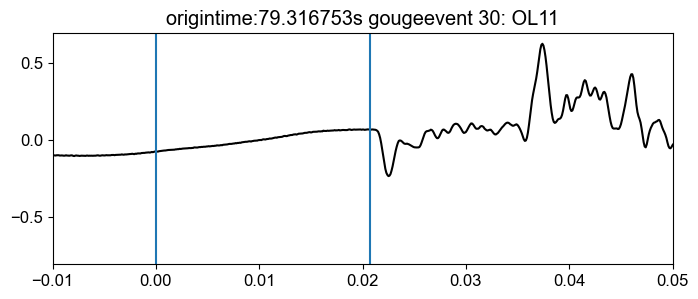

In [15]:
tr1 = read(outdir+"/obs_isocoord_OL11__fb03-087__0029.pickle")[0]
print(tr1.stats)

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.plot(tr1.times()*1e3-tr1.stats.pretrigger, tr1.data, "k-")
ax.axvline(0)
ax.axvline(tr1.stats.tpick)
ax.set_title(f"origintime:{tr1.stats.origintime}s gougeevent 30: {tr1.stats.station}")
ax.set_xlim([-tr1.stats.pretrigger, 0.05])

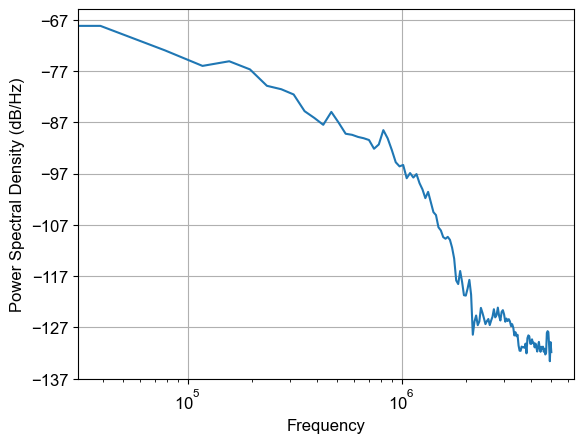

In [16]:
Pxx, freq = plt.psd(tr1.data, Fs=tr1.stats.sampling_rate)
ax = plt.gca()
ax.set_xscale('log')

In [17]:
plt.psd

<function matplotlib.pyplot.psd(x: 'ArrayLike', NFFT: 'int | None' = None, Fs: 'float | None' = None, Fc: 'int | None' = None, detrend: "Literal['none', 'mean', 'linear'] | Callable[[ArrayLike], ArrayLike] | None" = None, window: 'Callable[[ArrayLike], ArrayLike] | ArrayLike | None' = None, noverlap: 'int | None' = None, pad_to: 'int | None' = None, sides: "Literal['default', 'onesided', 'twosided'] | None" = None, scale_by_freq: 'bool | None' = None, return_line: 'bool | None' = None, *, data=None, **kwargs) -> 'tuple[np.ndarray, np.ndarray] | tuple[np.ndarray, np.ndarray, Line2D]'>

## Save green's function location file for OpenSWPC modeling

In [18]:
# save green txt for biax side coord
df_iso_all = pd.read_csv("../data/datacsv/AEevents_isocoord.csv",  index_col=[0])

fo = open("../data/datacsv/green_in_AEevent_biax.txt", "w")
fo.write("# AE event loc for green's function\n#     x     y    z    gid\n# --------------------------------------------------------------------------------------------\n")
gindex = 0
gindex_dict = {}
z_depth = 200e-3 #[m] depth on the fault

for index, row in df_iso_all.iterrows():
    xi1, eta1, zeta1, gid = [row["xi1"], row["eta1"], row["zeta1"], index]
    fo.write("{:.8e} {:.8e} {:.8e} {}\n".format(xi1/1e3, 0, -eta1/1e3, gindex)) # locations are in [km]
    print(index, gindex)
    gindex_dict[index] = gindex
#     print(gindex_dict)
    gindex = gindex+1
    
fo.close()

OL10__fb03-087__0017 0
OL10__fb03-087__0023 1
OL10__fb03-087__0029 2
OL10__fb03-087__0033 3
OL10__fb03-087__0036 4
OL10__fb03-087__0042 5
OL10__fb03-087__0065 6
OL10__fb03-087__0080 7
OL10__fb03-087__0090 8
OL10__fb03-087__0093 9
OL10__fb03-087__0103 10
OL10__fb03-087__0106 11
OL10__fb03-087__0107 12
OL10__fb03-087__0108 13
OL10__fb03-087__0114 14
OL10__fb03-087__0115 15
OL11__fb03-087__0017 16
OL11__fb03-087__0023 17
OL11__fb03-087__0029 18
OL11__fb03-087__0033 19
OL11__fb03-087__0036 20
OL11__fb03-087__0042 21
OL11__fb03-087__0065 22
OL11__fb03-087__0080 23
OL11__fb03-087__0090 24
OL11__fb03-087__0093 25
OL11__fb03-087__0103 26
OL11__fb03-087__0106 27
OL11__fb03-087__0107 28
OL11__fb03-087__0108 29
OL11__fb03-087__0114 30
OL11__fb03-087__0115 31
OL12__fb03-087__0017 32
OL12__fb03-087__0023 33
OL12__fb03-087__0029 34
OL12__fb03-087__0033 35
OL12__fb03-087__0036 36
OL12__fb03-087__0042 37
OL12__fb03-087__0065 38
OL12__fb03-087__0080 39
OL12__fb03-087__0090 40
OL12__fb03-087__0093 41
OL

In [19]:
# save green function index table
df_gindex = pd.DataFrame(gindex_dict.items(), columns=['index', 'gid'])
df_gindex.to_csv("../data/datacsv/gindex_table.csv") 

In [20]:
gindex_dict

{'OL10__fb03-087__0017': 0,
 'OL10__fb03-087__0023': 1,
 'OL10__fb03-087__0029': 2,
 'OL10__fb03-087__0033': 3,
 'OL10__fb03-087__0036': 4,
 'OL10__fb03-087__0042': 5,
 'OL10__fb03-087__0065': 6,
 'OL10__fb03-087__0080': 7,
 'OL10__fb03-087__0090': 8,
 'OL10__fb03-087__0093': 9,
 'OL10__fb03-087__0103': 10,
 'OL10__fb03-087__0106': 11,
 'OL10__fb03-087__0107': 12,
 'OL10__fb03-087__0108': 13,
 'OL10__fb03-087__0114': 14,
 'OL10__fb03-087__0115': 15,
 'OL11__fb03-087__0017': 16,
 'OL11__fb03-087__0023': 17,
 'OL11__fb03-087__0029': 18,
 'OL11__fb03-087__0033': 19,
 'OL11__fb03-087__0036': 20,
 'OL11__fb03-087__0042': 21,
 'OL11__fb03-087__0065': 22,
 'OL11__fb03-087__0080': 23,
 'OL11__fb03-087__0090': 24,
 'OL11__fb03-087__0093': 25,
 'OL11__fb03-087__0103': 26,
 'OL11__fb03-087__0106': 27,
 'OL11__fb03-087__0107': 28,
 'OL11__fb03-087__0108': 29,
 'OL11__fb03-087__0114': 30,
 'OL11__fb03-087__0115': 31,
 'OL12__fb03-087__0017': 32,
 'OL12__fb03-087__0023': 33,
 'OL12__fb03-087__0029':

In [21]:
df_gindex

,index,gid
0,OL10__fb03-087__0017,0
1,OL10__fb03-087__0023,1
2,OL10__fb03-087__0029,2
3,OL10__fb03-087__0033,3
4,OL10__fb03-087__0036,4
...,...,...
91,OL28__fb03-087__0106,91
92,OL28__fb03-087__0107,92
93,OL28__fb03-087__0108,93
94,OL28__fb03-087__0114,94


**NOTE** Now it's ready to conduct numerical simulation to compute Green's tensor.

# Output isoparametric sensor location for the Forward modeling
We output the sensor locations to run the forward modeling (i.e. turn off the  green's mode) to check the waveforms.

In [22]:
df_iso_all

,OL,datacase,xs,ys,zs,xi,eta,zeta,xi1,eta1,zeta1,incidentangle,azimuth,rlen_sourcedist,llen
OL10__fb03-087__0017,OL10,fb03-087__0017,2.410,0.05,0.07,2.7460,-0.00325,0,0.3360,-0.05325,0,81.180823,80.994539,0.347321,0.340193
OL10__fb03-087__0023,OL10,fb03-087__0023,2.410,0.05,0.07,2.7470,-0.00325,0,0.3370,-0.05325,0,81.205516,81.020826,0.348288,0.341181
OL10__fb03-087__0029,OL10,fb03-087__0029,2.410,0.05,0.07,2.7420,-0.00575,0,0.3320,-0.05575,0,80.669149,80.467728,0.343849,0.336648
OL10__fb03-087__0033,OL10,fb03-087__0033,2.410,0.05,0.07,2.7470,-0.01100,0,0.3370,-0.06100,0,79.950050,79.740044,0.349557,0.342476
OL10__fb03-087__0036,OL10,fb03-087__0036,2.410,0.05,0.07,2.7445,-0.00400,0,0.3345,-0.05400,0,81.020810,80.829575,0.345986,0.338831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OL28__fb03-087__0106,OL28,fb03-087__0106,3.035,-0.05,0.07,2.7455,-0.00175,0,0.2895,-0.04825,0,80.798123,80.537678,0.301726,0.293493
OL28__fb03-087__0107,OL28,fb03-087__0107,3.035,-0.05,0.07,2.7450,-0.00375,0,0.2900,-0.04625,0,81.187569,80.938621,0.301892,0.293665
OL28__fb03-087__0108,OL28,fb03-087__0108,3.035,-0.05,0.07,2.7445,-0.00100,0,0.2905,-0.04900,0,80.687450,80.425772,0.302806,0.294604
OL28__fb03-087__0114,OL28,fb03-087__0114,3.035,-0.05,0.07,2.7450,-0.00575,0,0.2900,-0.04425,0,81.563041,81.324372,0.301593,0.293357


In [23]:
ys_burry = 1e-3 #  [m] burry the sensor in the rock for the stability of computation

fo = open("../data/datacsv/stloc_forward.txt", "w")
fo.write("#      x     y     z       stnm   zsw\n# --------------------------------------------------------------------------------------------\n")

for index, row in df_iso_all.iterrows():
    sensor_x = row["xs"] - row["xi"]
    sensor_y = row["zs"]
    
    if row["ys"] > 0:
        # south side
        sensor_z = ys_burry
    else:
        # north side
        sensor_z = W/1e3 - ys_burry
        
    fo.write("{:.8e} {:.8e} {:.8e} {} dep\n".format(sensor_x/1e3, sensor_y/1e3, sensor_z/1e3, row["OL"])) # locations are in [km]
    
fo.close()


In [24]:
W/2/1e3

0.05

In [25]:
# # save green txt for side coordinate
# fo = open("../data/green_in_AEevent_sidecoord.txt", "w")
# fo.write("# AE event loc for green's function\n#     x     y    z    gid\n# --------------------------------------------------------------------------------------------\n")
# gindex = 0
# gindex_dict = {}
# for index, row in df_iso_all.iterrows():
#     xi1, eta1, zeta1, gid = [row["xi1"], row["eta1"], row["zeta1"], index]
#     fo.write("{:.8e} {:.8e} {:.8e} {}\n".format(xi1/1e3, z_depth/1e3, -eta1/1e3, gindex)) # locations are in [km]
#     gindex_dict[index] = gindex
#     gindex = gindex+1
    
# fo.close()

In [26]:
# # save green function index table
# df_gindex = pd.DataFrame(gindex_dict.items(), columns=['index', 'gid'])
# df_gindex.to_csv("../data/gindex_table_sidecoord.csv")